### Imports

In [27]:
import pandas as pd
import matplotlib.pyplot as plt

### Load Data

In [28]:
# Load results
df = pd.read_csv("/export/usuarios01/agnavarr/MALDIAlign/experiments/finetuning/results/grid_results_20260217_203414.csv")
df_msumg = pd.read_csv("/export/usuarios01/agnavarr/MALDIAlign/experiments/finetuning/results/grid_results_20260218_044246.csv")

### Utils

In [29]:
def plot_grid(df, title, ylim):

    models = [
        "RF_original",
        "RF_latent_zero",
        "RF_few",
        "FT_full",
        "FT_freeze_priors"
    ]

    label_map = {
        "RF_original": "RF (Source Only)",
        "RF_latent_zero": "RF (Latent, Zero-Shot)",
        "RF_few": "RF (Target Only)",
        "FT_full": "Fine-Tuning (Full)",
        "FT_freeze_priors": "Fine-Tuning (Frozen Priors)"
    }

    n_prev_values = sorted(df["n_prev"].unique())
    n_new_values  = sorted(df["n_new"].unique())

    fig, axes = plt.subplots(2, 3, figsize=(18, 10), sharex=True, sharey=True)
    axes = axes.flatten()

    for i, n_prev in enumerate(n_prev_values):
        ax = axes[i]
        df_row = df[df["n_prev"] == n_prev]

        for model in models:
            df_model = df_row[df_row["model"] == model].sort_values("n_new")

            if model == "RF_original":
                linestyle = "--"
                linewidth = 2
            elif model == "RF_latent_zero":
                linestyle = ":"
                linewidth = 2
            else:
                linestyle = "-"
                linewidth = 2.5

            ax.plot(
                df_model["n_new"],
                df_model["balanced_accuracy"],
                marker="o",
                linestyle=linestyle,
                linewidth=linewidth,
                label=label_map[model]
            )

        ax.set_title(f"Previous Domain Samples Used: {n_prev}", fontsize=12)
        ax.set_xticks(n_new_values)
        ax.grid(True, alpha=0.3)

    axes[0].set_ylim(*ylim)

    fig.supxlabel("Number of Few-Shot Target Samples (n_new)", fontsize=14)
    fig.supylabel("Balanced Accuracy", fontsize=14)

    fig.suptitle(
        title,
        fontsize=16,
        fontweight="bold",
        y=0.98
    )

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(
        handles,
        labels,
        loc="upper center",
        bbox_to_anchor=(0.5, 0.93),
        ncol=5,
        fontsize=11,
        frameon=False
    )

    plt.tight_layout(rect=[0, 0, 1, 0.9])
    plt.show()

### Plots

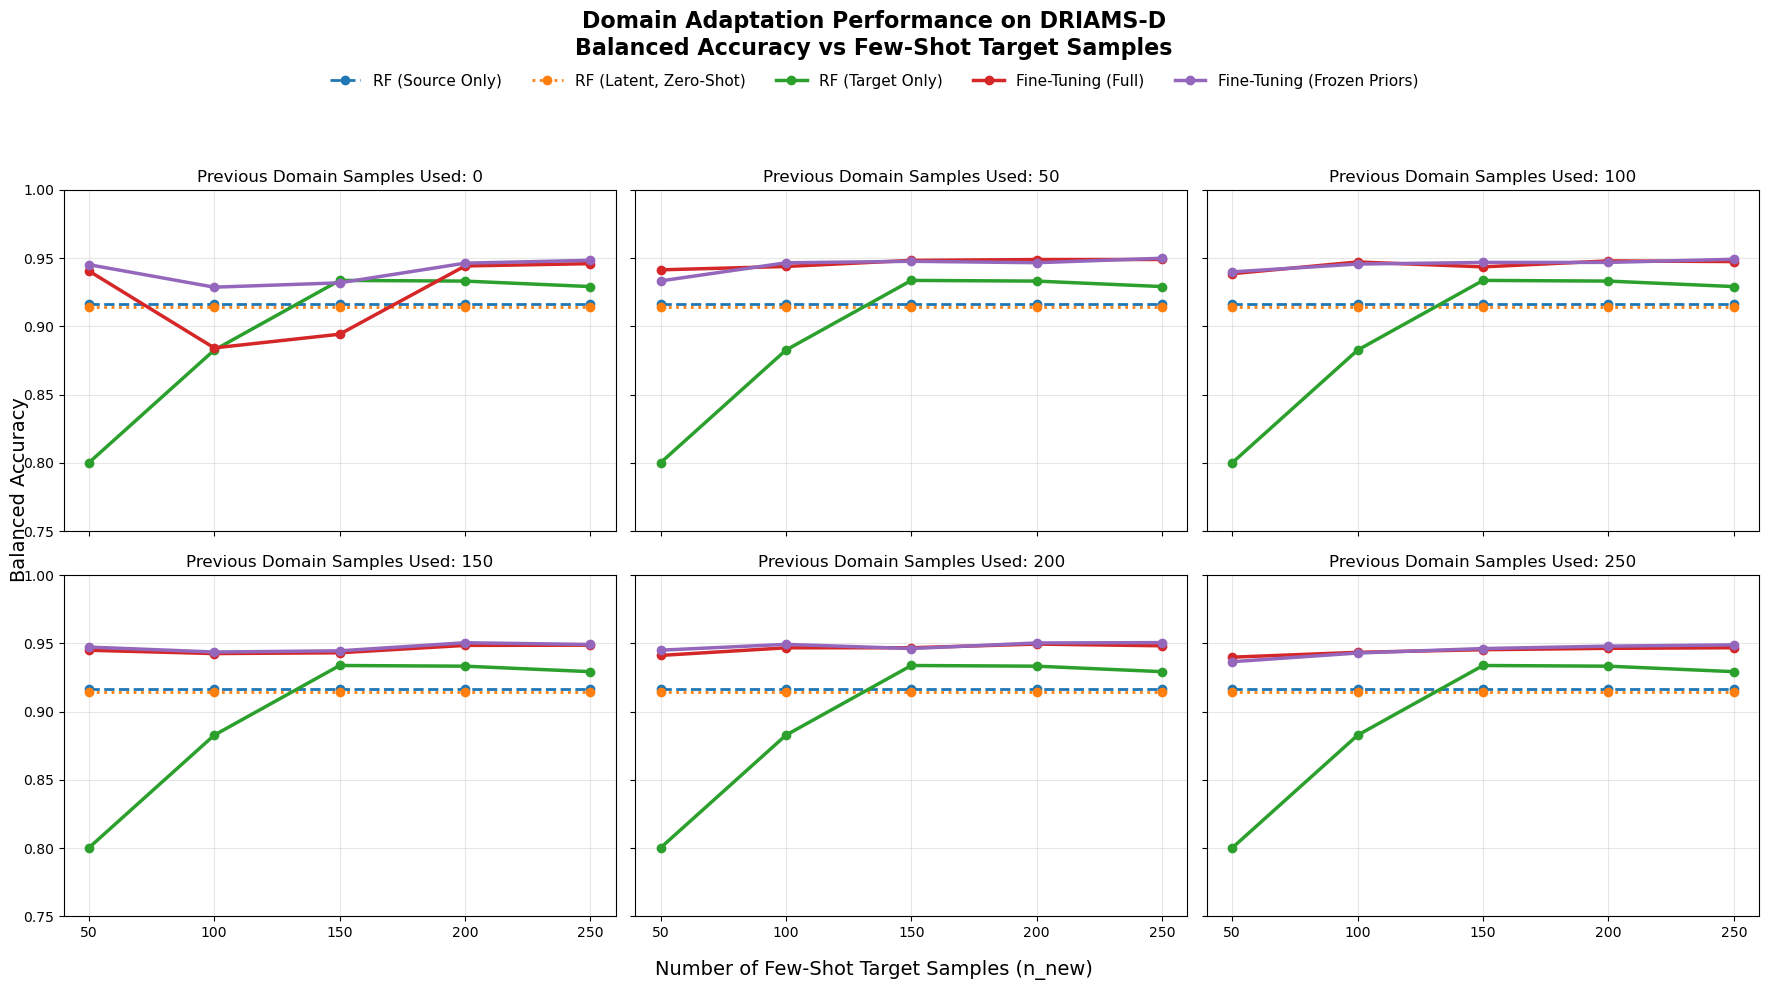

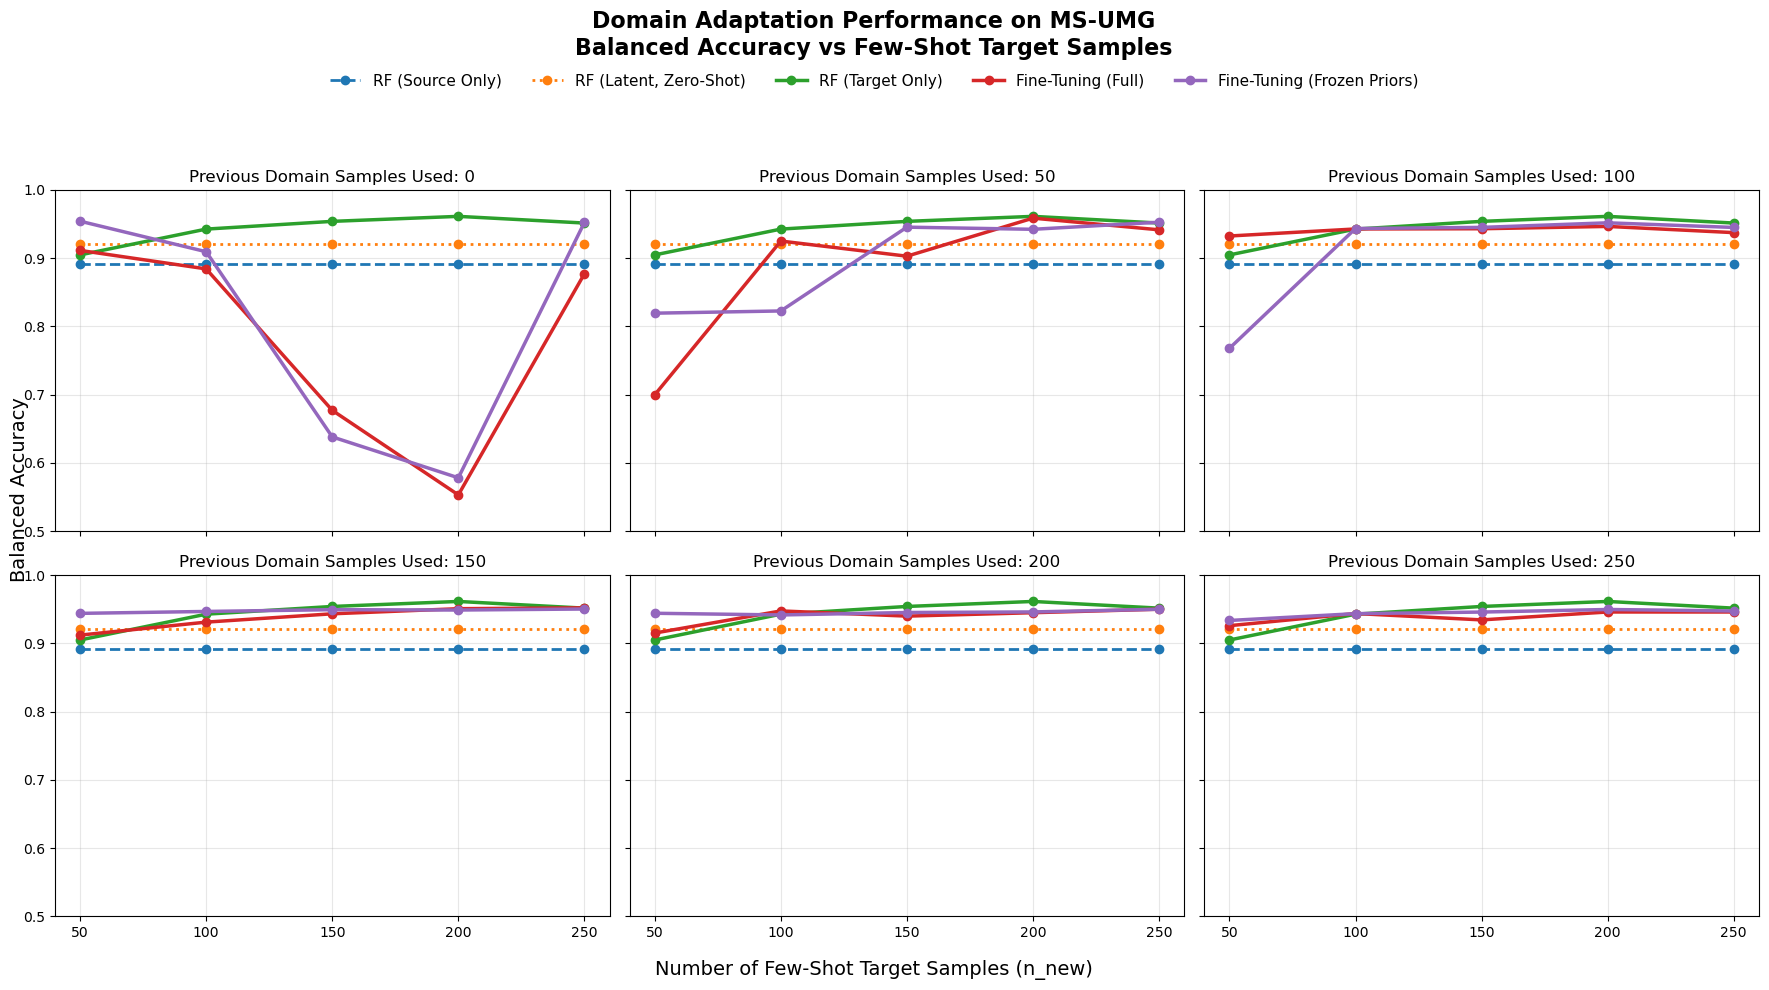

In [30]:
plot_grid(df, "Domain Adaptation Performance on DRIAMS-D\nBalanced Accuracy vs Few-Shot Target Samples", (0.75, 1.0))
plot_grid(df_msumg, "Domain Adaptation Performance on MS-UMG\nBalanced Accuracy vs Few-Shot Target Samples", (0.5, 1.0))